# Análisis Exploratorio de Datos — Olist
## Sustento de las decisiones sobre selección y tratamiento de los datos

---

## 1. Objetivo

El análisis recorre las tablas del e-commerce brasileño Olist para responder cuatro preguntas
previas al modelado:

1. ¿Qué tablas y qué columnas aportan información útil?
2. ¿Qué registros deben conservarse y cuáles descartarse?
3. ¿Qué variables requieren transformación antes de usarse en un modelo basado en distancias?
4. ¿Qué limitaciones del dataset condicionan el alcance del modelo?

Cada sección cierra con la decisión que se deriva de la evidencia observada.

In [1]:
# ==============================================================================
# 1.1 LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

c:\Users\Administrador\Desktop\TheHacht\Arquitectura_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Inventario de tablas

Olist distribuye la información en nueve tablas relacionales. El inventario permite identificar
cuáles contienen las variables necesarias para caracterizar productos y transacciones.

In [2]:
# ==============================================================================
# 2.1 CARGA E INVENTARIO
# ==============================================================================
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

tablas = {
    "orders":      pd.read_csv(f"{path}/olist_orders_dataset.csv"),
    "order_items": pd.read_csv(f"{path}/olist_order_items_dataset.csv"),
    "reviews":     pd.read_csv(f"{path}/olist_order_reviews_dataset.csv"),
    "products":    pd.read_csv(f"{path}/olist_products_dataset.csv"),
    "customers":   pd.read_csv(f"{path}/olist_customers_dataset.csv"),
    "sellers":     pd.read_csv(f"{path}/olist_sellers_dataset.csv"),
    "payments":    pd.read_csv(f"{path}/olist_order_payments_dataset.csv"),
    "geolocation": pd.read_csv(f"{path}/olist_geolocation_dataset.csv"),
    "traduccion":  pd.read_csv(f"{path}/product_category_name_translation.csv"),
}

inventario = pd.DataFrame(
    [{"tabla": k, "filas": len(v), "columnas": v.shape[1], "nulos_%": v.isna().mean().mean() * 100}
     for k, v in tablas.items()]
).sort_values("filas", ascending=False)

display(inventario.round(2))

,tabla,filas,columnas,nulos_%
7,geolocation,1000163,5,0.00
1,order_items,112650,7,0.00
6,payments,103886,5,0.00
0,orders,99441,8,0.62
4,customers,99441,5,0.00
2,reviews,99224,7,21.01
3,products,32951,9,0.83
5,sellers,3095,4,0.00
8,traduccion,71,2,0.00


**Decisión.** El modelado se centra en `orders`, `order_items`, `reviews` y `products`, que
contienen el identificador de producto, el precio, el flete, las dimensiones físicas y la
calificación. `customers`, `sellers`, `payments` y `geolocation` describen al comprador, al vendedor
y a la logística, dimensiones ajenas a la caracterización del producto.

## 3. Calidad de los datos

Se revisan valores faltantes y registros duplicados en las tablas seleccionadas.

In [3]:
# ==============================================================================
# 3.1 VALORES FALTANTES EN LAS TABLAS SELECCIONADAS
# ==============================================================================
for nombre in ["orders", "order_items", "reviews", "products"]:
    df = tablas[nombre]
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    print(f"--- {nombre} ({len(df):,} filas) ---")
    if nulos.empty:
        print("Sin valores faltantes.\n")
    else:
        display(pd.DataFrame({"nulos": nulos, "%": (nulos / len(df) * 100).round(2)}))

--- orders (99,441 filas) ---


,nulos,%
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98


--- order_items (112,650 filas) ---
Sin valores faltantes.

--- reviews (99,224 filas) ---


,nulos,%
review_comment_title,87656,88.34
review_comment_message,58247,58.70


--- products (32,951 filas) ---


,nulos,%
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [4]:
# ==============================================================================
# 3.2 DUPLICADOS EN LAS CLAVES PRINCIPALES
# ==============================================================================
print(f"order_id duplicados en orders:        {tablas['orders']['order_id'].duplicated().sum()}")
print(f"product_id duplicados en products:    {tablas['products']['product_id'].duplicated().sum()}")
print(f"order_id con más de una reseña:       {tablas['reviews']['order_id'].duplicated().sum()}")
print(f"órdenes con más de un ítem:           {tablas['order_items']['order_id'].duplicated().sum():,}")

order_id duplicados en orders:        0
product_id duplicados en products:    0
order_id con más de una reseña:       551
órdenes con más de un ítem:           13,984


**Decisión.** Las claves de `orders` y `products` son únicas, por lo que las uniones no generan
duplicación. Los faltantes de `products` se concentran en categoría y dimensiones físicas de una
fracción pequeña del catálogo: se imputan con la mediana en las variables físicas y con la etiqueta
`desconocido` en la categoría, en lugar de eliminar productos. Los campos de texto libre de
`reviews` presentan una proporción muy alta de vacíos y se descartan: sólo se conserva
`review_score`. Dado que una orden puede contener varios ítems, la agregación debe hacerse a nivel
de `product_id` y no de orden.

## 4. Estado de las órdenes

No todas las órdenes representan una venta concreta. La distribución de `order_status` determina
qué registros reflejan comportamiento real de compra.

,órdenes,%
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


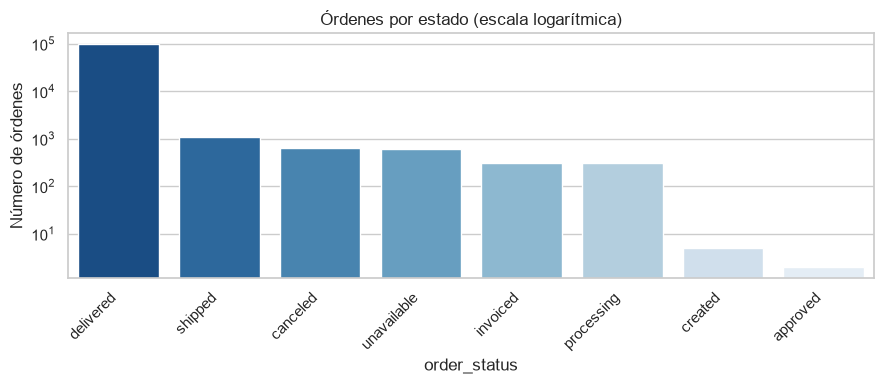

In [5]:
# ==============================================================================
# 4.1 DISTRIBUCIÓN DE ESTADOS
# ==============================================================================
estados = tablas["orders"]["order_status"].value_counts()
resumen = pd.DataFrame({"órdenes": estados, "%": (estados / len(tablas["orders"]) * 100).round(2)})
display(resumen)

plt.figure(figsize=(9, 4))
sns.barplot(x=estados.index, y=estados.values, hue=estados.index, legend=False, palette="Blues_r")
plt.yscale("log")
plt.title("Órdenes por estado (escala logarítmica)")
plt.ylabel("Número de órdenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Decisión.** Se conservan únicamente las órdenes con estado `delivered`, que concentran la
gran mayoría de los registros y son las únicas que garantizan una transacción completada y una
reseña coherente. Las órdenes canceladas, indisponibles o en tránsito introducirían ruido en el
cálculo de ventas y calificaciones por producto.

## 5. Variables comerciales y físicas del producto

Se consolida la información a nivel de producto y se examina la forma de las distribuciones, punto
crítico para cualquier algoritmo basado en distancias euclidianas.

In [6]:
# ==============================================================================
# 5.1 CONSOLIDACIÓN A NIVEL PRODUCTO
# ==============================================================================
orders_ok = tablas["orders"][tablas["orders"]["order_status"] == "delivered"]

df_base = (orders_ok
           .merge(tablas["order_items"][["order_id", "product_id", "price", "freight_value"]], on="order_id")
           .merge(tablas["reviews"][["order_id", "review_score"]], on="order_id", how="left"))

productos = tablas["products"].merge(tablas["traduccion"], on="product_category_name", how="left")
productos["categoria"] = productos["product_category_name_english"].fillna("desconocido")
productos["volumen_cm3"] = (productos["product_length_cm"]
                            * productos["product_height_cm"]
                            * productos["product_width_cm"])

df_prod = (df_base.groupby("product_id").agg(
        precio_promedio=("price", "mean"),
        flete_promedio=("freight_value", "mean"),
        total_ventas=("order_id", "count"),
        review_promedio=("review_score", "mean"),
    ).reset_index()
    .merge(productos[["product_id", "categoria", "product_weight_g", "volumen_cm3"]], on="product_id"))

print(f"Productos con al menos una venta entregada: {len(df_prod):,}")
display(df_prod.describe().T.round(2))

Productos con al menos una venta entregada: 32,216


,count,mean,std,min,25%,50%,75%,max
precio_promedio,"32,216.00",144.39,246.47,0.85,39.90,79.00,153.00,"6,735.00"
flete_promedio,"32,216.00",21.14,17.93,0.01,13.60,16.71,21.79,409.68
total_ventas,"32,216.00",3.44,10.65,1.00,1.00,1.00,3.00,520.00
review_promedio,"32,072.00",4.12,1.15,1.00,3.80,4.50,5.00,5.00
product_weight_g,"32,214.00","2,269.53","4,266.49",0.00,300.00,700.00,"1,900.00","40,425.00"
volumen_cm3,"32,214.00","16,435.30","26,822.46",168.00,"2,880.00","6,776.00","18,375.00","296,208.00"


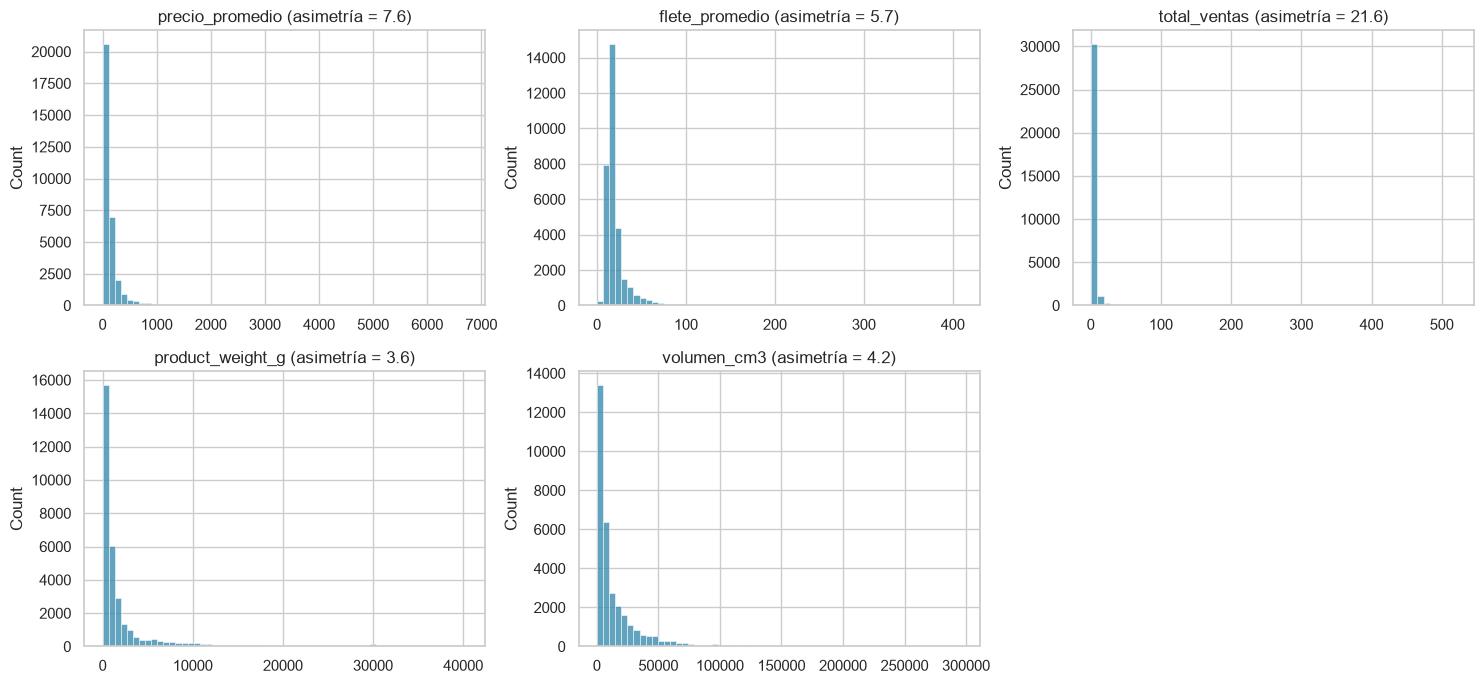

,mediana,media,percentil_99,máximo,asimetría
precio_promedio,79.00,144.39,"1,198.83","6,735.00",7.64
flete_promedio,16.71,21.14,99.28,409.68,5.67
total_ventas,1.00,3.44,33.00,520.00,21.57
product_weight_g,700.00,"2,269.53","22,437.00","40,425.00",3.61
volumen_cm3,"6,776.00","16,435.30","133,884.90","296,208.00",4.20


In [7]:
# ==============================================================================
# 5.2 FORMA DE LAS DISTRIBUCIONES
# ==============================================================================
variables = ["precio_promedio", "flete_promedio", "total_ventas", "product_weight_g", "volumen_cm3"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, var in zip(axes.flatten(), variables):
    sns.histplot(df_prod[var].dropna(), bins=60, ax=ax, color="#2E86AB")
    ax.set_title(f"{var} (asimetría = {df_prod[var].skew():.1f})")
    ax.set_xlabel("")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

concentracion = pd.DataFrame({
    "mediana": df_prod[variables].median(),
    "media": df_prod[variables].mean(),
    "percentil_99": df_prod[variables].quantile(0.99),
    "máximo": df_prod[variables].max(),
    "asimetría": df_prod[variables].skew(),
})
display(concentracion.round(2))

**Decisión.** Todas las variables presentan asimetría positiva marcada: la media supera
ampliamente a la mediana y el máximo se aleja varios órdenes de magnitud del percentil 99. En un
algoritmo que minimiza distancias al cuadrado, ese grupo reducido de valores extremos dominaría la
formación de los centroides. Se aplica la transformación $\log(1+x)$, que comprime la cola larga
conservando el orden relativo, en lugar de eliminar los productos atípicos, que son ventas
legítimas del catálogo.

## 6. Categorías del catálogo

La categoría es la variable que define la familia de un producto y actúa como filtro natural en un
sistema de recomendación.

Categorías distintas: 72
Las 10 mayores concentran el 63.1% del catálogo
Categorías con menos de 10 productos: 5


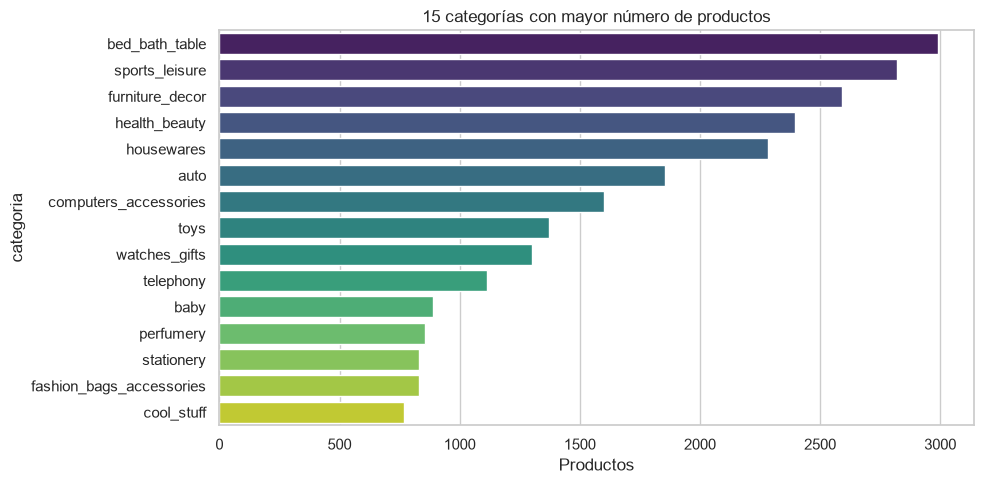

In [8]:
# ==============================================================================
# 6.1 CONCENTRACIÓN DE CATEGORÍAS
# ==============================================================================
cat_counts = df_prod["categoria"].value_counts()
cobertura = (cat_counts.cumsum() / cat_counts.sum() * 100)

print(f"Categorías distintas: {cat_counts.size}")
print(f"Las 10 mayores concentran el {cobertura.iloc[min(9, cat_counts.size - 1)]:.1f}% del catálogo")
print(f"Categorías con menos de 10 productos: {(cat_counts < 10).sum()}")

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.head(15).values, y=cat_counts.head(15).index,
            hue=cat_counts.head(15).index, legend=False, palette="viridis")
plt.title("15 categorías con mayor número de productos")
plt.xlabel("Productos")
plt.tight_layout()
plt.show()

**Decisión.** La distribución es muy desigual: un grupo reducido de categorías concentra la
mayor parte del catálogo y existe una cola de categorías con muy pocos productos. La categoría no se
incorpora como variable numérica al modelo —su codificación crearía decenas de dimensiones
dispersas— sino que se utiliza como filtro previo en la recomendación. El clustering se construye
sobre los atributos comerciales y físicos, y la coherencia de familia queda garantizada por el
filtro.

## 7. Volumen de ventas por producto

La frecuencia de venta determina la confiabilidad de los promedios calculados por producto.

Productos con una sola venta:      17,614 (54.7%)
Productos con más de 10 ventas:    1,653 (5.1%)
Ventas máximas de un producto:     520
El 5% de productos más vendidos genera el 42.1% de las ventas


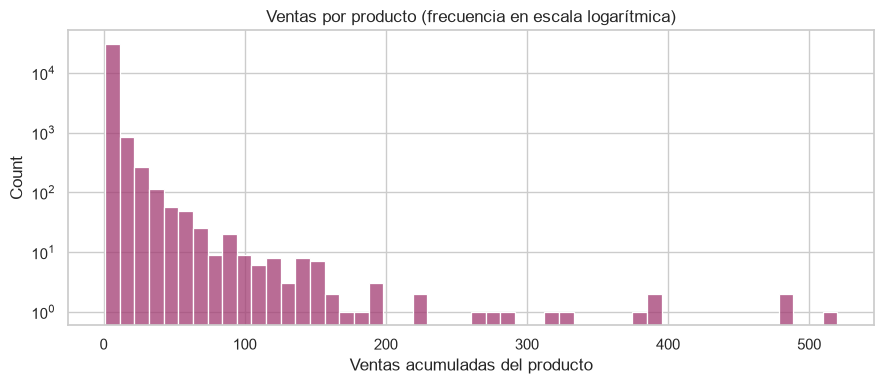

In [11]:
# ==============================================================================
# 7.1 DISTRIBUCIÓN DE VENTAS POR PRODUCTO
# ==============================================================================
ventas = df_prod["total_ventas"]
print(f"Productos con una sola venta:      {(ventas == 1).sum():,} ({(ventas == 1).mean() * 100:.1f}%)")
print(f"Productos con más de 10 ventas:    {(ventas > 10).sum():,} ({(ventas > 10).mean() * 100:.1f}%)")
print(f"Ventas máximas de un producto:     {ventas.max()}")

top_pct = df_prod.nlargest(int(len(df_prod) * 0.05), "total_ventas")["total_ventas"].sum() / ventas.sum() * 100
print(f"El 5% de productos más vendidos genera el {top_pct:.1f}% de las ventas")

plt.figure(figsize=(9, 4))
sns.histplot(ventas, bins=50, color="#A23B72")
plt.yscale("log")
plt.title("Ventas por producto (frecuencia en escala logarítmica)")
plt.xlabel("Ventas acumuladas del producto")
plt.tight_layout()
plt.show()

**Decisión.** El catálogo responde a un patrón de cola larga: la mayoría de los productos
registra muy pocas ventas y una minoría concentra el grueso de la facturación. Los productos de baja
rotación se conservan, porque un recomendador debe cubrir la totalidad del catálogo, pero la
variable de ventas se transforma logarítmicamente para que los superventas no distorsionen los
grupos. Se registra como limitación que la calificación promedio de un producto con una única venta
tiene escasa estabilidad estadística.

## 8. Calificaciones

Ítems sin calificación asociada: 0.75%
Calificación media global:       4.08


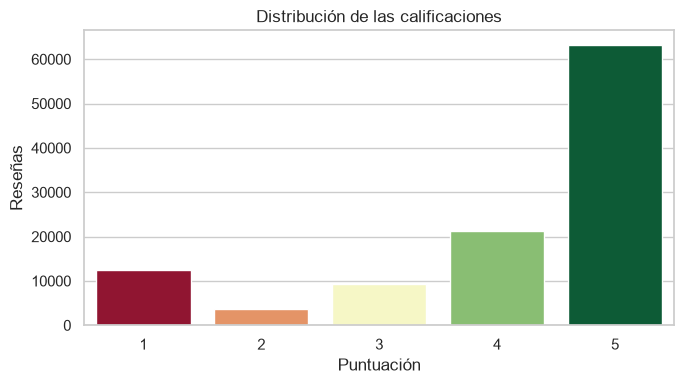

In [9]:
# ==============================================================================
# 8.1 DISTRIBUCIÓN Y COBERTURA DE LAS RESEÑAS
# ==============================================================================
scores = df_base["review_score"].value_counts().sort_index()
print(f"Ítems sin calificación asociada: {df_base['review_score'].isna().mean() * 100:.2f}%")
print(f"Calificación media global:       {df_base['review_score'].mean():.2f}")

plt.figure(figsize=(7, 4))
sns.barplot(x=scores.index.astype(int), y=scores.values,
            hue=scores.index.astype(int), legend=False, palette="RdYlGn")
plt.title("Distribución de las calificaciones")
plt.xlabel("Puntuación")
plt.ylabel("Reseñas")
plt.tight_layout()
plt.show()

**Decisión.** La distribución está sesgada hacia las puntuaciones altas y la cobertura de
reseñas es casi total. Los pocos productos sin calificación se imputan con la media global, opción
neutra que evita descartar registros y no altera la posición relativa del resto del catálogo.

## 9. Relación entre variables

La correlación entre las variables candidatas indica si alguna aporta información redundante.

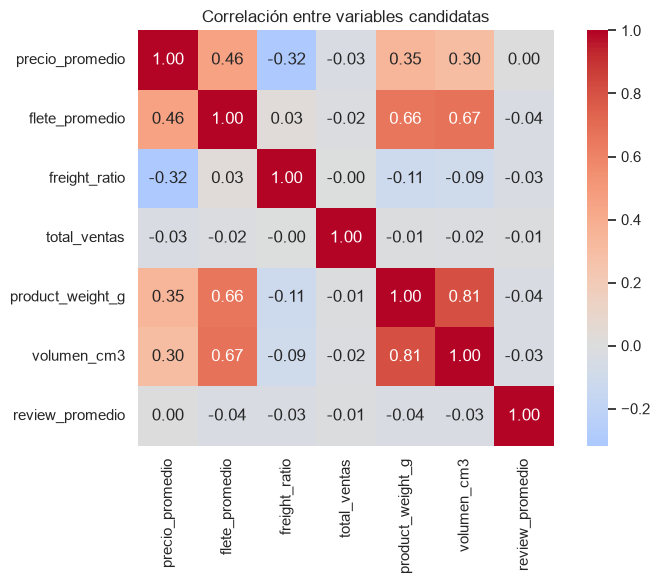

In [10]:
# ==============================================================================
# 9.1 MATRIZ DE CORRELACIÓN DE LAS VARIABLES CANDIDATAS
# ==============================================================================
df_prod["freight_ratio"] = (df_prod["flete_promedio"] / df_prod["precio_promedio"]).fillna(0)
df_prod["freight_ratio"] = df_prod["freight_ratio"].clip(upper=df_prod["freight_ratio"].quantile(0.999))

candidatas = ["precio_promedio", "flete_promedio", "freight_ratio",
              "total_ventas", "product_weight_g", "volumen_cm3", "review_promedio"]

plt.figure(figsize=(8, 6))
sns.heatmap(df_prod[candidatas].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlación entre variables candidatas")
plt.tight_layout()
plt.show()

**Decisión.** Peso y volumen mantienen una correlación alta pero no total: describen productos
grandes y ligeros de forma distinta a productos pequeños y densos, por lo que ambas se conservan. El
flete se asocia principalmente al tamaño y no al precio, lo que justifica incorporar el ratio
flete/precio como variable derivada: distingue productos económicos con envío costoso de productos
caros con envío proporcionalmente bajo, información que ninguna variable original aporta por sí
sola. La calificación se mantiene por su valor comercial pese a su baja correlación con el resto.

## 10. Frecuencia de compra por cliente

Olist identifica al comprador con dos claves distintas: `customer_id`, única por orden, y
`customer_unique_id`, estable a través de las distintas compras de una misma persona. Contar
órdenes por `customer_unique_id` permite saber si el negocio tiene una base de clientes recurrentes
o si la mayoría compra una sola vez.

Clientes únicos con al menos una compra entregada: 93,358
Clientes con una sola compra:                      90,557 (97.0%)
Clientes con dos o más compras:                     2,801 (3.0%)
Promedio de compras por cliente:                    1.03
Máximo de compras de un mismo cliente:               15


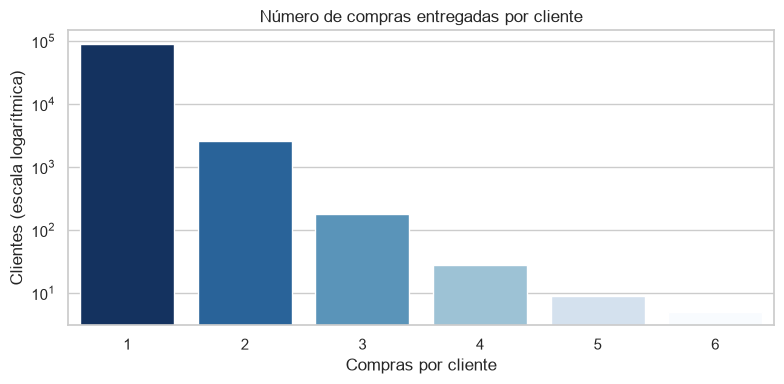

In [12]:
# ==============================================================================
# 10.1 ÓRDENES POR CLIENTE ÚNICO
# ==============================================================================
customers = tablas["customers"][["customer_id", "customer_unique_id"]]

ordenes_cliente = (orders_ok
                   .merge(customers, on="customer_id")
                   .groupby("customer_unique_id")["order_id"]
                   .nunique())

clientes_unicos = ordenes_cliente.size
una_compra = (ordenes_cliente == 1).sum()

print(f"Clientes únicos con al menos una compra entregada: {clientes_unicos:,}")
print(f"Clientes con una sola compra:                      {una_compra:,} ({una_compra / clientes_unicos * 100:.1f}%)")
print(f"Clientes con dos o más compras:                     {clientes_unicos - una_compra:,} "
      f"({(clientes_unicos - una_compra) / clientes_unicos * 100:.1f}%)")
print(f"Promedio de compras por cliente:                    {ordenes_cliente.mean():.2f}")
print(f"Máximo de compras de un mismo cliente:               {ordenes_cliente.max()}")

distribucion = ordenes_cliente.value_counts().sort_index()
distribucion_top = distribucion.head(6)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=distribucion_top.index.astype(int), y=distribucion_top.values,
            hue=distribucion_top.index.astype(int), legend=False, palette="Blues_r", ax=ax)
ax.set_yscale("log")
ax.set_title("Número de compras entregadas por cliente")
ax.set_xlabel("Compras por cliente")
ax.set_ylabel("Clientes (escala logarítmica)")
plt.tight_layout()
plt.show()

## 10. Síntesis de decisiones

| Ámbito | Evidencia del análisis | Decisión |
|---|---|---|
| Tablas | Sólo cuatro tablas describen al producto | Uso de `orders`, `order_items`, `reviews` y `products` |
| Registros | Los estados distintos de `delivered` no reflejan ventas completadas | Filtro por órdenes entregadas |
| Granularidad | Una orden puede contener varios ítems | Agregación a nivel `product_id` |
| Faltantes | Nulos acotados en dimensiones, categoría y reseñas | Imputación por mediana y media global |
| Distribuciones | Asimetría elevada en precio, flete, ventas, peso y volumen | Transformación logarítmica en lugar de eliminación de atípicos |
| Escala | Rangos muy dispares entre variables | Estandarización previa al clustering |
| Categoría | Alta cardinalidad y distribución desigual | Uso como filtro de recomendación, no como variable del modelo |
| Variables derivadas | El flete se explica por el tamaño, no por el precio | Incorporación del ratio flete/precio |
| Cola larga | Mayoría de productos con muy pocas ventas | Se conservan; se asume menor estabilidad en sus promedios |

El conjunto resultante consolida un registro por producto con variables comerciales y físicas
transformadas y escaladas, apto para segmentación mediante K-Means y para la construcción de un
sistema de recomendación por similitud.